In [1]:
#import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
#dataset load  and overview 
df = pd.read_csv("../data/machine_learning_dataset_filtered.csv")

df.head()

print(df.shape)
df.info()

df.describe().T

(131, 144)
<class 'pandas.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Columns: 144 entries, SampleID to Disease
dtypes: float64(142), str(2)
memory usage: 147.5 KB


,count,mean,std,min,25%,50%,75%,max
Collinsella,131.0,0.076086,0.056955,0.000000,0.032610,0.065586,0.105467,0.298546
Blautia,131.0,0.154536,0.080485,0.002932,0.091372,0.141201,0.206667,0.367091
Romboutsia,131.0,0.063892,0.063857,0.000000,0.009489,0.044065,0.099387,0.262366
Clostridium sensu stricto 1,131.0,0.090024,0.097556,0.000254,0.015854,0.064057,0.134544,0.615693
Catenibacterium,131.0,0.042519,0.061860,0.000000,0.000282,0.013375,0.059185,0.295283
...,...,...,...,...,...,...,...,...
Shuttleworthia,131.0,0.000014,0.000052,0.000000,0.000000,0.000000,0.000000,0.000435
Murdochiella,131.0,0.000014,0.000053,0.000000,0.000000,0.000000,0.000000,0.000427
Holdemania,131.0,0.000010,0.000041,0.000000,0.000000,0.000000,0.000000,0.000305
Fastidiosipila,131.0,0.000007,0.000025,0.000000,0.000000,0.000000,0.000000,0.000161


In [3]:
#class distributions 

df["Disease"].value_counts()
df["Disease"].value_counts(normalize = True)*100

Disease
Type 2 diabetes    50.381679
Healthy            49.618321
Name: proportion, dtype: float64

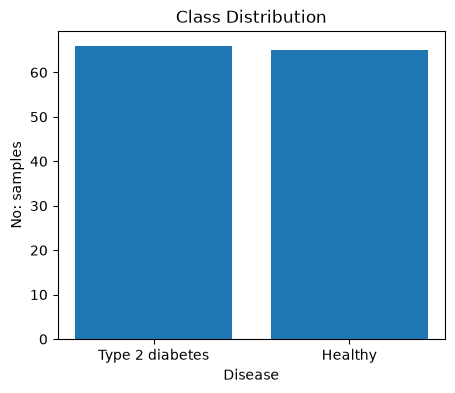

In [21]:
counts = df["Disease"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Disease")
plt.ylabel("No: samples")
plt.title("Class Distribution")
plt.savefig("../figures/class_distributions.png", dpi=800, bbox_inches="tight")
plt.show()

In [5]:
#separate features

x = df.drop(columns = ["SampleID", "Disease"])
y = df["Disease"]

In [6]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
Collinsella,131.0,0.076086,0.056955,0.000000,0.032610,0.065586,0.105467,0.298546
Blautia,131.0,0.154536,0.080485,0.002932,0.091372,0.141201,0.206667,0.367091
Romboutsia,131.0,0.063892,0.063857,0.000000,0.009489,0.044065,0.099387,0.262366
Clostridium sensu stricto 1,131.0,0.090024,0.097556,0.000254,0.015854,0.064057,0.134544,0.615693
Catenibacterium,131.0,0.042519,0.061860,0.000000,0.000282,0.013375,0.059185,0.295283
...,...,...,...,...,...,...,...,...
Shuttleworthia,131.0,0.000014,0.000052,0.000000,0.000000,0.000000,0.000000,0.000435
Murdochiella,131.0,0.000014,0.000053,0.000000,0.000000,0.000000,0.000000,0.000427
Holdemania,131.0,0.000010,0.000041,0.000000,0.000000,0.000000,0.000000,0.000305
Fastidiosipila,131.0,0.000007,0.000025,0.000000,0.000000,0.000000,0.000000,0.000161


In [7]:
zero_fraction = (x == 0).sum().sum()/x.size

print(f"Fraction of zeros: {zero_fraction:.2%}")

Fraction of zeros: 49.29%


In [8]:
mean_abundance = x.mean().sort_values(ascending=False)

mean_abundance.head(20)

Blautia                            0.154536
Clostridium sensu stricto 1        0.090024
Collinsella                        0.076086
Romboutsia                         0.063892
Bifidobacterium                    0.045273
Catenibacterium                    0.042519
Holdemanella                       0.039752
[Eubacterium] hallii group         0.036928
Dorea                              0.035685
Subdoligranulum                    0.031581
Ruminococcus                       0.023223
Erysipelotrichaceae UCG-003        0.023133
[Ruminococcus] torques group       0.021071
Streptococcus                      0.018698
Turicibacter                       0.012951
Anaerostipes                       0.012381
Enterococcus                       0.010145
[Ruminococcus] gauvreauii group    0.009862
Senegalimassilia                   0.009628
Terrisporobacter                   0.009469
dtype: float64

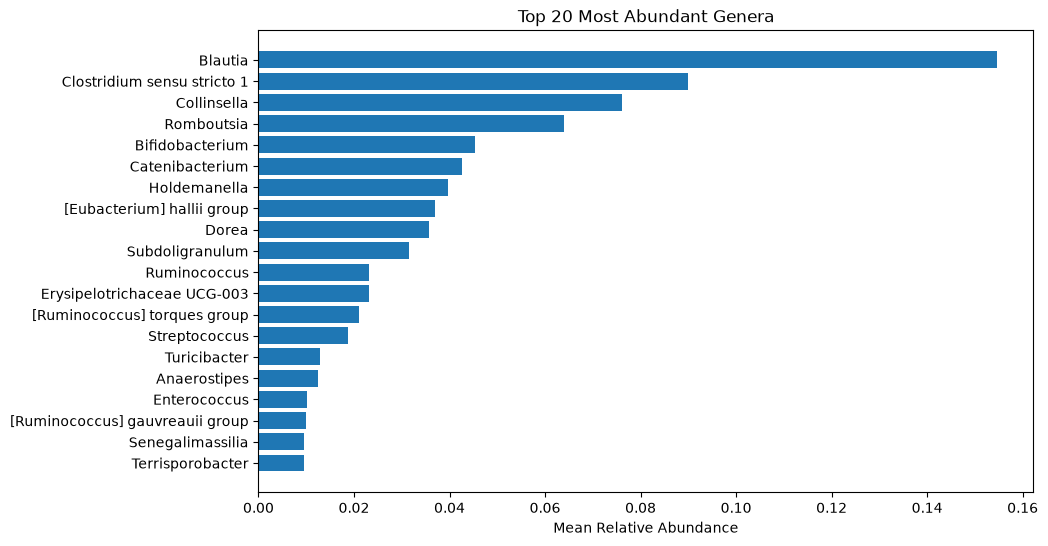

In [9]:
top20 = mean_abundance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20.index[::-1], top20.values[::-1])
plt.xlabel("Mean Relative Abundance")
plt.title("Top 20 Most Abundant Genera")
plt.show()

In [10]:
#most prevalent genera

prevalence = (x > 0).sum()

prevalence.sort_values(ascending=False).head(20)

Blautia                            131
Clostridium sensu stricto 1        131
[Eubacterium] hallii group         131
Dorea                              131
Coprococcus                        131
Anaerostipes                       131
[Ruminococcus] torques group       130
Family XIII AD3011 group           129
Faecalibacterium                   129
Actinomyces                        129
Subdoligranulum                    129
Ruminococcus                       128
Marvinbryantia                     128
Collinsella                        128
[Ruminococcus] gauvreauii group    128
UCG-002                            126
Fusicatenibacter                   126
Streptococcus                      126
Romboutsia                         126
Intestinibacter                    124
dtype: int64

In [11]:
corr = x.corr()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = (upper.abs() > 0.90).sum().sum()

print(high_corr)

14


In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

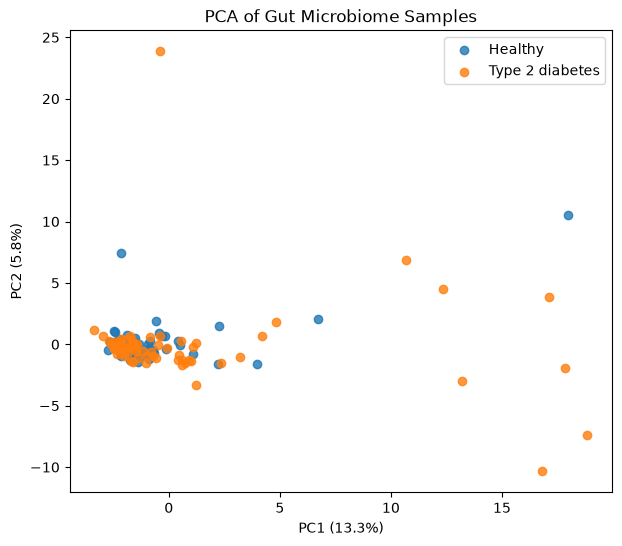

In [13]:
plt.figure(figsize=(7,6))

for label in y.unique():
    idx = y == label
    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=label,
        alpha=0.8
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.legend()

plt.title("PCA of Gut Microbiome Samples")

plt.show()

In [24]:
df.to_csv("../data/eda_dataset.csv", index=False)

In [25]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Cumulative variance:")
print(np.cumsum(pca.explained_variance_ratio_)[:10])

Explained variance ratio:
[0.13267233 0.05790375]
Cumulative variance:
[0.13267233 0.19057608]


In [26]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Disease": y
})

pca_df.sort_values("PC1", ascending=False).head(10)

,PC1,PC2,Disease
29,18.848600,-7.397267,Type 2 diabetes
113,17.951950,10.503464,Healthy
37,17.842023,-1.929079,Type 2 diabetes
89,17.103743,3.822663,Type 2 diabetes
26,16.822955,-10.357145,Type 2 diabetes
36,13.205193,-2.987018,Type 2 diabetes
25,12.363534,4.535575,Type 2 diabetes
84,10.698358,6.830061,Type 2 diabetes
111,6.705678,2.078497,Healthy
27,4.835427,1.800003,Type 2 diabetes


In [28]:
from sklearn.decomposition import PCA

pca_all = PCA()

pca_all.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

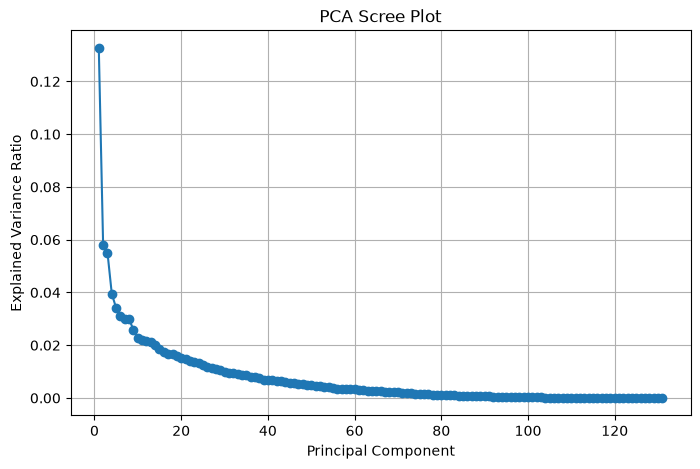

In [29]:
explained = pca_all.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()

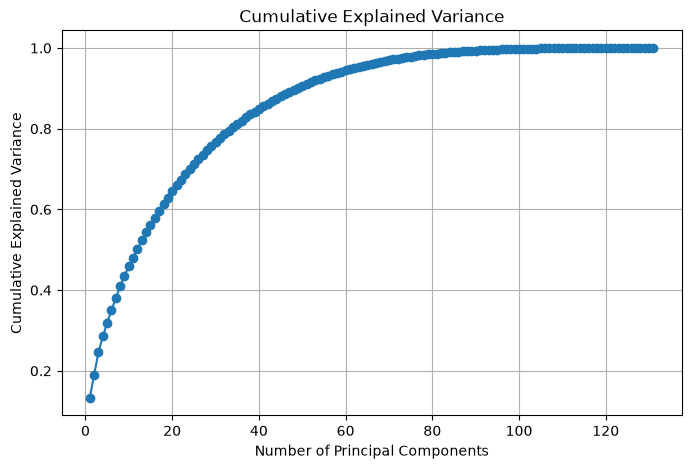

In [30]:
cum_var = np.cumsum(pca_all.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [31]:
n80 = np.argmax(cum_var >= 0.80) + 1
print(f"{n80} principal components explain at least 80% of the variance.")

34 principal components explain at least 80% of the variance.


In [14]:
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    """
    Create a covariance confidence ellipse.
    """
    if len(x) < 2:
        return

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])

    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    ellipse = Ellipse(
        (0, 0),
        width=2 * ell_radius_x,
        height=2 * ell_radius_y,
        fill=False,
        **kwargs
    )

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    transf = (
        transforms.Affine2D()
        .rotate_deg(45)
        .scale(scale_x, scale_y)
        .translate(mean_x, mean_y)
    )

    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

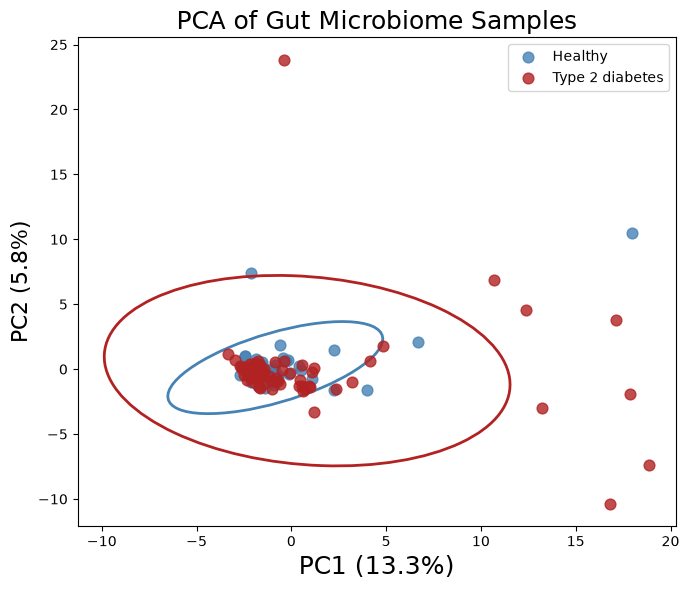

In [23]:
fig, ax = plt.subplots(figsize=(7,6))

colors = {
    "Healthy": "steelblue",
    "Type 2 diabetes": "firebrick"
}

for label in y.unique():

    idx = y == label

    ax.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=label,
        alpha=0.8,
        s=60,
        color=colors[label]
    )

    confidence_ellipse(
        X_pca[idx,0],
        X_pca[idx,1],
        ax,
        n_std=2,
        edgecolor=colors[label],
        linewidth=2
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=18)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=16)

ax.set_title("PCA of Gut Microbiome Samples",  fontsize=18)

ax.legend()

plt.tight_layout()

plt.savefig("../figures/PCA_with_ellipses.png", dpi=1200, bbox_inches="tight")

plt.show()